# 🌾 MODULE 3: HUẤN LUYỆN MÔ HÌNH PHÂN LOẠI CHẤT LƯỢNG HẠT LÚA (DENSENET121)
**Đề tài Nghiên cứu Khoa học**: Hệ thống thị giác máy tính và học sâu phục vụ ước lượng số lượng và đánh giá phẩm cấp hạt giống lúa.

### Các cải tiến:
1. **resize_with_pad (Letterbox)** thay vì resize méo tỷ lệ — giữ đúng aspect ratio hạt lúa.
2. **Lọc ảnh nhỏ** min_side < 20px (nhiễu segmentation).
3. **Class Weights tự động** cân bằng mất cân bằng lớp ~1:4.3.
4. **Data Augmentation 360°** cho hạt lúa (bất biến góc quay).
5. **Vòng lặp so sánh tự động** 4 bộ dữ liệu v3_step1–step4.


In [2]:
# Bước 1: Kết nối Google Drive & Cài đặt thư viện
from google.colab import drive
drive.mount('/content/drive')

!pip install tensorflow scikit-learn matplotlib seaborn numpy pillow pandas


Mounted at /content/drive


In [3]:
!unzip -q "/content/DATA2.zip" -d "/content/DATA2/"

In [12]:
# Bước 2: Import thư viện & Cấu hình Tham số
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import pandas as pd
from pathlib import Path
from PIL import Image
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# ─────────────────────────────────────────────────────────────────────
BASE_PATH = "/content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/"

# 4 bộ dữ liệu cần so sánh
# DATASET_STEPS = {
#     "v3_step1": os.path.join(BASE_PATH, "DETECTED_OBJECTS/DATA2/OUTPUT_CLEANED_GRAINS_v3_step1"),
#     "v3_step2": os.path.join(BASE_PATH, "DETECTED_OBJECTS/DATA2/OUTPUT_CLEANED_GRAINS_v3_step2"),
#     "v3_step3": os.path.join(BASE_PATH, "DETECTED_OBJECTS/DATA2/OUTPUT_CLEANED_GRAINS_v3_step3"),
#     "v3_step4": os.path.join(BASE_PATH, "DETECTED_OBJECTS/DATA2/OUTPUT_CLEANED_GRAINS_v3_step4"),
# }

DATASET_STEPS = {
    "v3_step1": "/content/DATA2/DATA2sub/OUTPUT_CLEANED_GRAINS_v3_step1",
    "v3_step2": "/content/DATA2/DATA2sub/OUTPUT_CLEANED_GRAINS_v3_step2",
    "v3_step3": "/content/DATA2/DATA2sub/OUTPUT_CLEANED_GRAINS_v3_step3",
    "v3_step4": "/content/DATA2/DATA2sub/OUTPUT_CLEANED_GRAINS_v3_step4",
}

SAVE_MODEL_DIR = os.path.join(BASE_PATH, "RESULTS/CNN_DenseNet121_Trained")
os.makedirs(SAVE_MODEL_DIR, exist_ok=True)

IMG_SIZE    = (224, 224)   # Kích thước chuẩn DenseNet121
BATCH_SIZE  = 16
SEED        = 42
MIN_SIZE_PX = 20           # Lọc ảnh crop có min(w,h) < 20px
NUM_CLASSES = 2

print("=" * 60)
print(f"💾 SAVE_MODEL_DIR : {SAVE_MODEL_DIR}")
print(f"⚙️  IMG: {IMG_SIZE} | Batch: {BATCH_SIZE} | MinSize: {MIN_SIZE_PX}px")
print("📂 Datasets:")
for k, v in DATASET_STEPS.items(): print(f"  {k}: {v}")
print("=" * 60)


💾 SAVE_MODEL_DIR : /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/CNN_DenseNet121_Trained
⚙️  IMG: (224, 224) | Batch: 16 | MinSize: 20px
📂 Datasets:
  v3_step1: /content/DATA2/DATA2sub/OUTPUT_CLEANED_GRAINS_v3_step1
  v3_step2: /content/DATA2/DATA2sub/OUTPUT_CLEANED_GRAINS_v3_step2
  v3_step3: /content/DATA2/DATA2sub/OUTPUT_CLEANED_GRAINS_v3_step3
  v3_step4: /content/DATA2/DATA2sub/OUTPUT_CLEANED_GRAINS_v3_step4


In [5]:
# Buoc 3: Pipeline chuan hoa du lieu
# [Fix 1] resize_with_pad (letterbox) giu dung ty le khung hinh
# [Fix 2] Loc anh tiny bang file SIZE (bytes) thay vi PIL.Image.open()
#          -> tuong thich voi Google Drive (PIL khong on dinh tren FUSE path)
#          -> MIN_FILE_BYTES = 500: loai anh < 500 bytes (nhieu segmentation ro rang)

MIN_FILE_BYTES = 500   # anh PNG < 500 bytes la nhieu (< 20x20px tren thuc te)

def collect_filtered_paths(dataset_dir, min_bytes=MIN_FILE_BYTES):
    # Duyệt cac thu muc nhan, loc anh co file size < min_bytes
    label_dirs  = sorted([d for d in Path(dataset_dir).iterdir() if d.is_dir()])
    class_names = [d.name for d in label_dirs]
    cls2idx = {c: i for i, c in enumerate(class_names)}
    fps, lbs, skipped = [], [], 0
    for ld in label_dirs:
        for p in sorted(ld.glob('*.png')):
            try:
                fsize = p.stat().st_size   # chi doc metadata, KHONG mo file
                if fsize >= min_bytes:
                    fps.append(str(p))
                    lbs.append(cls2idx[ld.name])
                else:
                    skipped += 1
            except Exception:
                skipped += 1
    print(f"  OK: {len(fps)} anh | Loai bo (<{min_bytes} bytes): {skipped}")
    for cn in class_names:
        print(f"    [{cn}]: {lbs.count(cls2idx[cn])}")
    return fps, lbs, class_names


@tf.function
def load_and_pad(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_png(raw, channels=3)
    img = tf.cast(img, tf.float32)
    img = tf.image.resize_with_pad(img, IMG_SIZE[0], IMG_SIZE[1])
    lbl = tf.one_hot(label, depth=NUM_CLASSES)
    return img, lbl


def build_datasets(dataset_dir, min_bytes=MIN_FILE_BYTES, val_r=0.15, test_r=0.15):
    fps, lbs, class_names = collect_filtered_paths(dataset_dir, min_bytes)
    idx = list(range(len(fps)))
    random.seed(SEED); random.shuffle(idx)
    fps = [fps[i] for i in idx]
    lbs = [lbs[i] for i in idx]
    n = len(fps)
    nt = int(n * test_r); nv = int(n * val_r); nn = n - nv - nt

    def ds(paths, labels, shuf=False):
        d = tf.data.Dataset.from_tensor_slices(
            (tf.constant(paths), tf.constant(labels, dtype=tf.int32)))
        d = d.map(load_and_pad, num_parallel_calls=tf.data.AUTOTUNE)
        d = d.cache()
        if shuf: d = d.shuffle(min(2000, len(paths)), seed=SEED)
        return d.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    tr = ds(fps[:nn],          lbs[:nn],          True)
    va = ds(fps[nn:nn+nv],     lbs[nn:nn+nv],     False)
    te = ds(fps[nn+nv:],       lbs[nn+nv:],       False)
    print(f"  Chia: Train={nn} | Val={nv} | Test={nt}")

    arr = np.array(lbs[:nn])
    w   = compute_class_weight('balanced', classes=np.unique(arr), y=arr)
    cw  = dict(enumerate(w))
    print(f"  Class Weights: {cw}")
    return tr, va, te, class_names, cw


# Kiem tra nhanh pipeline voi v3_step1
print('='*60)
print('Kiem tra pipeline voi v3_step1...')
_tr, _va, _te, _cls, _cw = build_datasets(DATASET_STEPS['v3_step1'])
print(f'Lop: {_cls}')
for imgs, lbls in _tr.take(1):
    print(f'Batch shape: imgs={imgs.shape} labels={lbls.shape}')
    print(f'Output 224x224: {imgs.shape[1]==224 and imgs.shape[2]==224}')
del _tr, _va, _te


Kiem tra pipeline voi v3_step1...
  OK: 8610 anh | Loai bo (<500 bytes): 103
    [hat_khuyet_tat]: 6957
    [hat_nguyen]: 1653
  Chia: Train=6028 | Val=1291 | Test=1291
  Class Weights: {0: np.float64(0.6220846233230134), 1: np.float64(2.547759932375317)}
Lop: ['hat_khuyet_tat', 'hat_nguyen']
Batch shape: imgs=(16, 224, 224, 3) labels=(16, 2)
Output 224x224: True


In [6]:
# Bước 4: Thiết kế kiến trúc DenseNet121
# (Sử dụng trong ham build_model() ở cell so sánh)

def build_model(n_classes=NUM_CLASSES):
    aug = tf.keras.Sequential([
        layers.RandomFlip('horizontal_and_vertical'),
        layers.RandomRotation(1.0),
        layers.RandomZoom(0.15),
        layers.RandomContrast(0.2),
    ], name='augmentation')
    base = DenseNet121(weights='imagenet', include_top=False,
                       input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    base.trainable = False
    inp = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x   = aug(inp)
    x   = layers.Lambda(preprocess_input, name='densenet_preprocess')(x)
    x   = base(x, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dense(128, activation='relu')(x)
    x   = layers.Dropout(0.4)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    return models.Model(inp, out), base

print('build_model() da san sang.')


build_model() da san sang.


---
## So sanh 4 buoc xu ly anh

Vong lap duoi day se:
1. Xay dung dataset tu tung `v3_step*` voi pipeline da chuan (letterbox + loc anh nho).
2. Xay dung lai model DenseNet121 (warmup -> fine-tune) cho tung step.
3. Danh gia tren tap Test doc lap, luu Classification Report.
4. Tong hop bang so sanh **Macro F1-Score** cuoi cung.


In [7]:
# Vong lap Train + Evaluate tu dong 4 steps
comparison_results = {}

for step_name, step_dir in DATASET_STEPS.items():
    print('\n' + '='*70)
    print(f'TRAIN: {step_name}')
    print('='*70)

    train_ds, val_ds, test_ds, class_names, cw = build_datasets(step_dir)
    model, base_model = build_model(len(class_names))

    # Phase 1: Warmup
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    cb1 = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6),
    ]
    print('  [Phase 1] Warmup...')
    model.fit(train_ds, validation_data=val_ds, epochs=25, class_weight=cw, callbacks=cb1, verbose=1)

    # Phase 2: Fine-Tune 60 layers cuoi
    base_model.trainable = True
    for layer in base_model.layers[:-60]: layer.trainable = False
    best_path = os.path.join(SAVE_MODEL_DIR, f'best_{step_name}.keras')
    model.compile(optimizer=tf.keras.optimizers.Adam(5e-5),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    cb2 = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint(best_path, monitor='val_accuracy', save_best_only=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7),
    ]
    print('  [Phase 2] Fine-Tune 60 layers cuoi...')
    model.fit(train_ds, validation_data=val_ds, epochs=50, class_weight=cw, callbacks=cb2, verbose=1)

    # Evaluate
    print('  [Eval] Danh gia tap Test...')
    y_true, y_pred = [], []
    for imgs, lbls in test_ds:
        preds = model.predict(imgs, verbose=0)
        y_true.extend(np.argmax(lbls.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    rd   = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, digits=4)
    rtxt = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    with open(os.path.join(SAVE_MODEL_DIR, f'report_{step_name}.txt'), 'w', encoding='utf-8') as rf:
        rf.write(f'Step: {step_name}\n' + rtxt)
    print(rtxt)

    comparison_results[step_name] = {
        'Macro F1':        round(rd['macro avg']['f1-score'],                     4),
        'Accuracy':        round(rd['accuracy'],                                  4),
        'Recall (nguyen)': round(rd.get('hat_nguyen', {}).get('recall',    0),    4),
        'Prec  (nguyen)':  round(rd.get('hat_nguyen', {}).get('precision', 0),    4),
        'F1   (nguyen)':   round(rd.get('hat_nguyen', {}).get('f1-score',  0),    4),
    }

    del model, base_model, train_ds, val_ds, test_ds
    tf.keras.backend.clear_session()

print('HOAN TAT 4 STEPS!')



TRAIN: v3_step1
  OK: 8610 anh | Loai bo (<500 bytes): 103
    [hat_khuyet_tat]: 6957
    [hat_nguyen]: 1653
  Chia: Train=6028 | Val=1291 | Test=1291
  Class Weights: {0: np.float64(0.6220846233230134), 1: np.float64(2.547759932375317)}
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
  [Phase 1] Warmup...
Epoch 1/25
377/377 ━━━━━━━━━━━━━━━━━━━━ 67s 119ms/step - accuracy: 0.8568 - loss: 0.3080 - val_accuracy: 0.8590 - val_loss: 0.2671 - learning_rate: 0.0010
Epoch 2/25
377/377 ━━━━━━━━━━━━━━━━━━━━ 38s 101ms/step - accuracy: 0.8676 - loss: 0.2671 - val_accuracy: 0.8428 - val_loss: 0.3068 - learning_rate: 0.0010
Epoch 3/25
377/377 ━━━━━━━━━━━━━━━━━━━━ 37s 99ms/step - accuracy: 0.8724 - loss: 0.2477 - val_accuracy: 0.8451 - val_loss: 0.3480 - learning_rate: 0.0010
Epoch 4/25
377/377 ━━━━━━━━━━━━━━━━━━━━ 38s 102ms/step - accuracy: 0.8756 - loss: 0.2453 - val_accuracy: 0.8513 - val_loss: 0.3502 - learning_rate: 0.0010
Epoch 5/25
377/377 ━━━━━━━━━━━━━━━━━━━━ 39s 103ms/step - accuracy: 0.


  KET QUA SO SANH 4 BUOC XU LY ANH (Macro F1 giam dan)
          Macro F1  Accuracy  Recall (nguyen)  Prec  (nguyen)  F1   (nguyen)
Step                                                                        
v3_step2    0.8664    0.9094           0.9779          0.6637         0.7907
v3_step3    0.8411    0.8908           0.9469          0.6239         0.7522
v3_step4    0.8398    0.8877           0.9735          0.6128         0.7521
v3_step1    0.8295    0.8799           0.9602          0.5978         0.7368

Buoc tot nhat: v3_step2  (Macro F1 = 0.8664)
Da luu bang so sanh tai: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/CNN_DenseNet121_Trained/comparison_results_4steps.csv


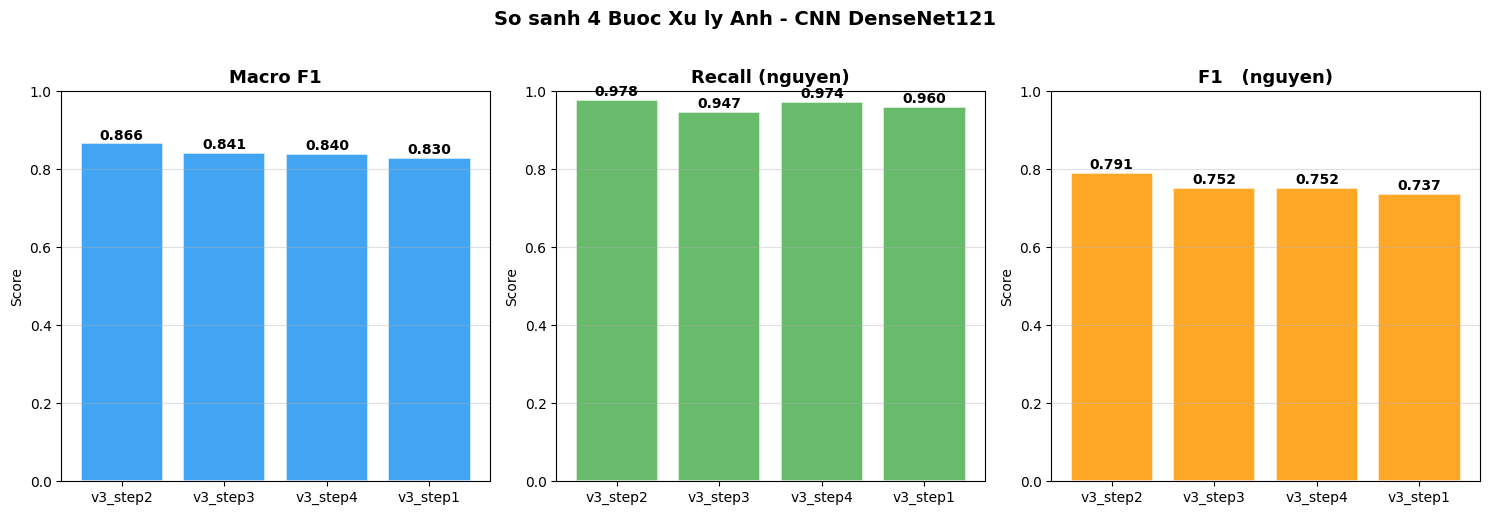

Da luu bieu do tai: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/CNN_DenseNet121_Trained/comparison_chart_4steps.png


In [8]:
# Bang tong hop ket qua so sanh 4 steps
df = pd.DataFrame(comparison_results).T
df.index.name = 'Step'
df = df.sort_values('Macro F1', ascending=False)

print('\n' + '='*70)
print('  KET QUA SO SANH 4 BUOC XU LY ANH (Macro F1 giam dan)')
print('='*70)
print(df.to_string())
print(f"\nBuoc tot nhat: {df.index[0]}  (Macro F1 = {df['Macro F1'].iloc[0]:.4f})")

csv_path = os.path.join(SAVE_MODEL_DIR, 'comparison_results_4steps.csv')
df.to_csv(csv_path, encoding='utf-8-sig')
print(f'Da luu bang so sanh tai: {csv_path}')

# Bieu do so sanh
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['Macro F1', 'Recall (nguyen)', 'F1   (nguyen)']
colors  = ['#2196F3', '#4CAF50', '#FF9800']
for ax, metric, color in zip(axes, metrics, colors):
    ax.bar(df.index, df[metric], color=color, alpha=0.85, edgecolor='white', linewidth=1.2)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.0); ax.set_ylabel('Score'); ax.grid(axis='y', alpha=0.4)
    for i, v in enumerate(df[metric]):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
plt.suptitle('So sanh 4 Buoc Xu ly Anh - CNN DenseNet121', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
chart = os.path.join(SAVE_MODEL_DIR, 'comparison_chart_4steps.png')
plt.savefig(chart, dpi=150, bbox_inches='tight'); plt.show()
print(f'Da luu bieu do tai: {chart}')


---
## Du doan thu cho anh bat ky

Upload anh hat lua len `/content` roi chay cell duoi de xem nhan va xac suat.


Nhan: hat_khuyet_tat | Confidence: 100.00%
  hat_khuyet_tat: 1.0000
  hat_nguyen: 0.0000


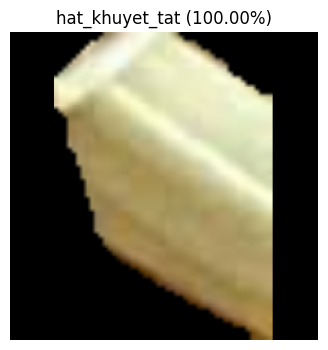

In [24]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.densenet import preprocess_input # Import preprocess_input

UPLOAD_FROM_COMPUTER = False
CUSTOM_TEST_IMAGE_PATH = '/content/test1_grain_0132.png'
MODEL_TO_USE = os.path.join(SAVE_MODEL_DIR, 'best_v3_step2.keras')  # Doi step neu can
INFERENCE_CLASS_NAMES = ['hat_khuyet_tat', 'hat_nguyen']

def predict_single_grain(image_path, model_path, class_names):
    if not os.path.exists(image_path):
        print(f'Khong tim thay: {image_path}'); return
    loaded_model = tf.keras.models.load_model(model_path, compile=False, safe_mode=False, custom_objects={'preprocess_input': preprocess_input})
    img_bgr = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if img_bgr.shape[-1] == 4:
        bgr = img_bgr[:,:,:3]; alpha = img_bgr[:,:,3]
        bgr[alpha == 0] = [0,0,0]
    else:
        bgr = img_bgr
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).astype('float32')
    h, w = rgb.shape[:2]
    scale = 224 / max(h, w)
    nh, nw = int(h*scale), int(w*scale)
    resized = cv2.resize(rgb, (nw, nh))
    padded  = np.zeros((224, 224, 3), dtype='float32')
    ph, pw  = (224-nh)//2, (224-nw)//2
    padded[ph:ph+nh, pw:pw+nw] = resized
    tensor = np.expand_dims(padded, 0)
    preds  = loaded_model.predict(tensor, verbose=0)[0]
    idx    = int(np.argmax(preds))
    print(f'Nhan: {class_names[idx]} | Confidence: {preds[idx]:.2%}')
    for i, cn in enumerate(class_names): print(f'  {cn}: {preds[i]:.4f}')
    plt.figure(figsize=(4,4))
    plt.imshow(padded.astype('uint8')); plt.title(f'{class_names[idx]} ({preds[idx]:.2%})')
    plt.axis('off'); plt.show()

if UPLOAD_FROM_COMPUTER:
    from google.colab import files
    uploaded = files.upload()
    CUSTOM_TEST_IMAGE_PATH = list(uploaded.keys())[0]

predict_single_grain(CUSTOM_TEST_IMAGE_PATH, MODEL_TO_USE, INFERENCE_CLASS_NAMES)

In [27]:
# Kiểm tra trực tiếp các file và hiển thị đường dẫn chính xác
import os
if os.path.exists(SAVE_MODEL_DIR):
    files = os.listdir(SAVE_MODEL_DIR)
    keras_models = [f for f in files if f.endswith('.keras')]
    print(f"--- DANH SÁCH ĐƯỜNG DẪN MÔ HÌNH --- ")
    for m in sorted(keras_models):
        full_path = os.path.abspath(os.path.join(SAVE_MODEL_DIR, m))
        size_mb = os.path.getsize(full_path) / (1024 * 1024)
        print(f"File: {m}")
        print(f"Path: {full_path}")
        print(f"Size: {size_mb:.2f} MB")
        print("-" * 30)
else:
    print(f"Lỗi: Không tìm thấy thư mục tại {SAVE_MODEL_DIR}")

--- DANH SÁCH ĐƯỜNG DẪN MÔ HÌNH --- 
File: best_v3_step1.keras
Path: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/CNN_DenseNet121_Trained/best_v3_step1.keras
Size: 39.43 MB
------------------------------
File: best_v3_step2.keras
Path: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/CNN_DenseNet121_Trained/best_v3_step2.keras
Size: 39.43 MB
------------------------------
File: best_v3_step3.keras
Path: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/CNN_DenseNet121_Trained/best_v3_step3.keras
Size: 39.43 MB
------------------------------
File: best_v3_step4.keras
Path: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/CNN_DenseNet121_Trained/best_v3_step4.keras
Size: 39.43 MB
------------------------------


In [28]:
from google.colab import drive

# Lệnh này sẽ đẩy toàn bộ dữ liệu đang chờ đồng bộ lên server
# Lưu ý: Sau khi chạy bạn có thể cần mount lại để tiếp tục dùng Drive
print("Đang ép đồng bộ dữ liệu với Google Drive...")
try:
    drive.flush_and_unmount()
    print("Đã Flush thành công. Đang mount lại...")
    drive.mount('/content/drive')
    print("Hoàn tất! Kiểm tra lại giao diện Drive của bạn.")
except Exception as e:
    print(f"Thông báo: {e}")

Đang ép đồng bộ dữ liệu với Google Drive...
Đã Flush thành công. Đang mount lại...
Mounted at /content/drive
Hoàn tất! Kiểm tra lại giao diện Drive của bạn.
